In [17]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error , mean_absolute_error , r2_score

In [18]:
df = pd.read_csv("temperatures.csv")

In [19]:
monthly_feature = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']
pca_month = PCA(n_components =1)
df['pca_month'] = pca_month.fit_transform(df[monthly_feature])
df = df.drop(monthly_feature,axis=1)

In [20]:
mat_corr = df.corr()
top_correlated_features = mat_corr['pca_month'].abs().sort_values(ascending = False).head(3).index.tolist()
top_correlated_features.remove('pca_month')
print("TOP CORRELATED FEATURES ARE :",top_correlated_features)

TOP CORRELATED FEATURES ARE : ['ANNUAL', 'JAN-FEB']


In [21]:
X = df[['ANNUAL']]
y = df['pca_month']

In [22]:
metrics ={"train_size":[],"sse_train":[],"sse_test":[]}
simple = LinearRegression()
for train_size in np.arange(0.1,1.0,0.1):
    X_train , X_test , y_train , y_test = train_test_split(X,y,train_size = train_size,random_state = 42)
    model = simple.fit(X_train , y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    sse_train = np.sum((y_train - y_train_pred)**2)
    sse_test = np.sum((y_test - y_test_pred)**2)
    metrics['train_size'].append(train_size)
    metrics['sse_train'].append(sse_train)
    metrics['sse_test'].append(sse_test)

In [23]:
best_train_index = np.argmin(metrics['sse_test'])
best_train_size = metrics['train_size'][best_train_index]
print("\nBEST TRAINING SIZE : ",best_train_size)


BEST TRAINING SIZE :  0.9


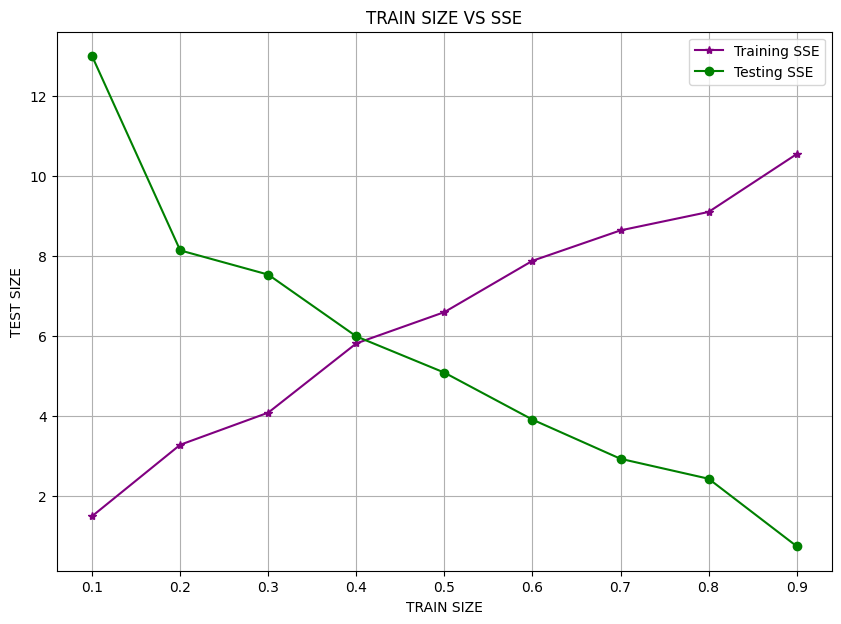

In [24]:
plt.figure(figsize=(10,7))
plt.plot(metrics['train_size'],metrics['sse_train'],marker='*',color ='purple',label='Training SSE')
plt.plot(metrics['train_size'],metrics['sse_test'],marker='o',color ='green',label='Testing SSE')
plt.title('TRAIN SIZE VS SSE')
plt.xlabel('TRAIN SIZE')
plt.ylabel('TEST SIZE')
plt.legend()
plt.grid(True)
plt.show()

In [25]:
X_train , X_test , y_train , y_test = train_test_split(X,y,train_size = best_train_size,random_state=42)
final_model = simple.fit(X_train, y_train)
y_train_pred = final_model.predict(X_train)
y_test_pred = final_model.predict(X_test)

In [26]:
mse_train = mean_squared_error(y_train , y_train_pred)
mse_test = mean_squared_error(y_test , y_test_pred)

print(f"\nTRAINING MSE : {mse_train:.2f}")
print(f"\nTESTING MSE : {mse_test:.2f}")

mae_train = mean_absolute_error(y_train , y_train_pred)
mae_test = mean_absolute_error(y_test , y_test_pred)

print(f"\nTRAINING MAE : {mae_train:.2f}")
print(f"\nTESTING MAE : {mae_test:.2f}")

r2_train = r2_score(y_train , y_train_pred)
r2_test = r2_score(y_test , y_test_pred)

print(f"\nTRAINING R2 SCORE : {r2_train:.2f}")
print(f"\nTESTING R2 SCORE : {r2_test:.2f}")


TRAINING MSE : 0.10

TESTING MSE : 0.06

TRAINING MAE : 0.25

TESTING MAE : 0.20

TRAINING R2 SCORE : 0.98

TESTING R2 SCORE : 0.98


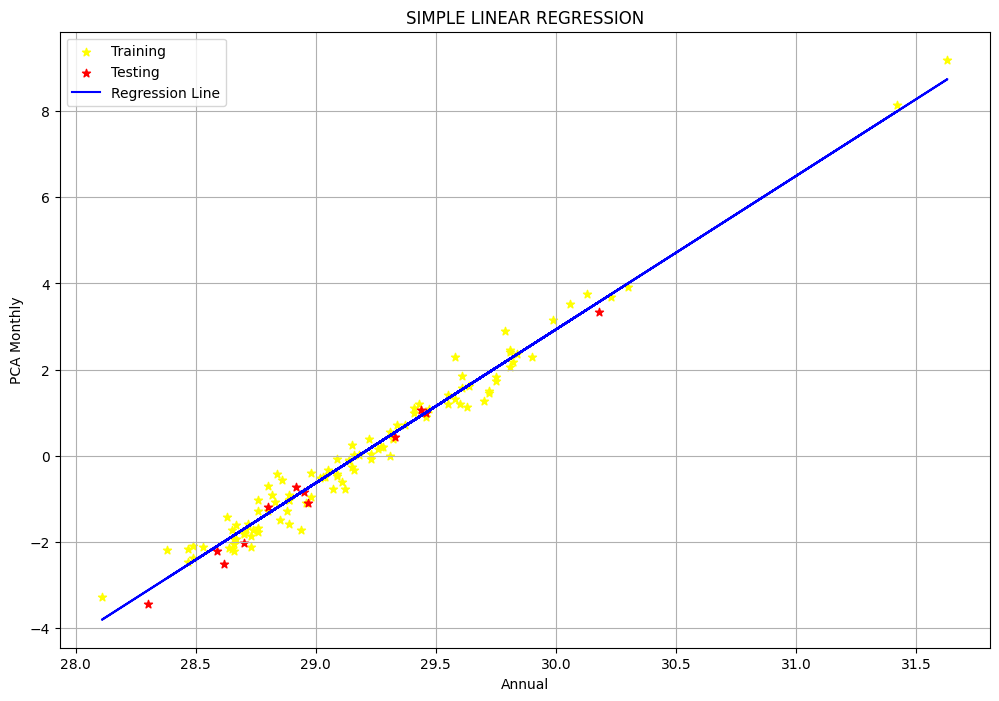

In [29]:
plt.figure(figsize=(12,8))
plt.scatter(X_train, y_train, marker='*',color='yellow',label='Training')
plt.scatter(X_test, y_test, marker='*',color='red',label='Testing')
plt.plot(X_train , y_train_pred , linestyle='-',color='blue',label='Regression Line')
plt.title('SIMPLE LINEAR REGRESSION')
plt.xlabel('Annual')
plt.ylabel('PCA Monthly')
plt.grid(True)
plt.legend()
plt.show()

C:\Users\akshi\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


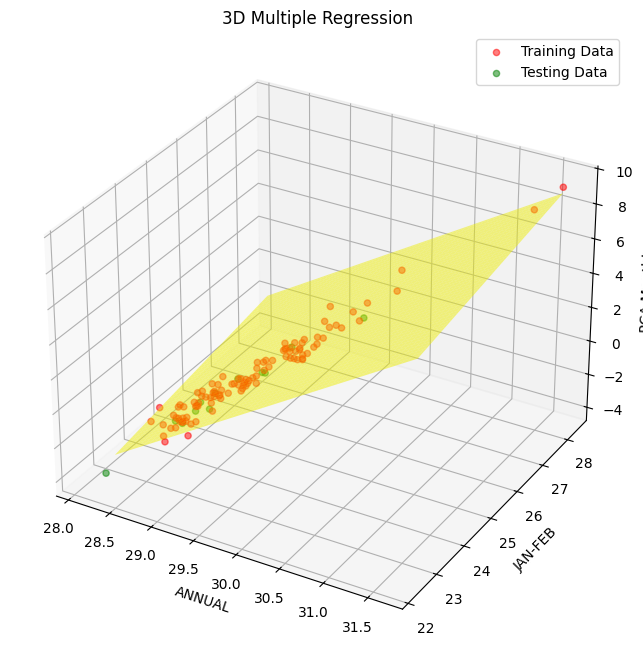

In [36]:
from mpl_toolkits.mplot3d import Axes3D

# Use the top 2 correlated features for 3D regression
top_features = top_correlated_features[:2]
X_3D = df[top_features]
y_3D = df['pca_month']

# Train-test split
X_train_3D, X_test_3D, y_train_3D, y_test_3D = train_test_split(X_3D, y_3D, train_size=best_train_size, random_state=42)

# Fit a Linear Regression model for 3D
model_3D = LinearRegression().fit(X_train_3D, y_train_3D)

# Create grid for regression surface
x1_range = np.linspace(X_train_3D[top_features[0]].min(), X_train_3D[top_features[0]].max(), 100)
x2_range = np.linspace(X_train_3D[top_features[1]].min(), X_train_3D[top_features[1]].max(), 100)
x1_mesh, x2_mesh = np.meshgrid(x1_range, x2_range)
y_pred_surface = model_3D.predict(np.column_stack((x1_mesh.ravel(), x2_mesh.ravel()))).reshape(x1_mesh.shape)

# 3D Plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot actual points and regression surface
ax.scatter(X_train_3D[top_features[0]], X_train_3D[top_features[1]], y_train_3D, color='red', alpha=0.5, label='Training Data')
ax.scatter(X_test_3D[top_features[0]], X_test_3D[top_features[1]], y_test_3D, color='green', alpha=0.5, label='Testing Data')
ax.plot_surface(x1_mesh, x2_mesh, y_pred_surface, color='yellow', alpha=0.5)

# Labels and title
ax.set_xlabel(top_features[0])
ax.set_ylabel(top_features[1])
ax.set_zlabel('PCA Monthly')
plt.title('3D Multiple Regression')
plt.legend()
plt.show()
